In [7]:
# =============================
# 1. IMPORTS
# =============================
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import json

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [8]:
# =============================
# 2. TRANSFORMS
# =============================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [10]:
# =============================
# 3. LOAD DATA
# =============================
train_data = datasets.ImageFolder("../dataset/train", transform=train_transform)
test_data = datasets.ImageFolder("../dataset/test", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print("Number of classes:", len(train_data.classes))

Number of classes: 90


In [11]:
# =============================
# 4. LOAD MODEL (ResNet)
# =============================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer
num_classes = len(train_data.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [12]:
# =============================
# 5. TRAINING SETUP
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Using device: cuda


In [13]:
# =============================
# 6. TRAINING LOOP
# =============================
epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch 1/10, Loss: 2.9843, Accuracy: 44.19%
Epoch 2/10, Loss: 1.2917, Accuracy: 83.15%
Epoch 3/10, Loss: 0.7186, Accuracy: 91.16%
Epoch 4/10, Loss: 0.4414, Accuracy: 95.69%
Epoch 5/10, Loss: 0.2692, Accuracy: 97.89%
Epoch 6/10, Loss: 0.1774, Accuracy: 99.00%
Epoch 7/10, Loss: 0.1167, Accuracy: 99.63%
Epoch 8/10, Loss: 0.0772, Accuracy: 99.81%
Epoch 9/10, Loss: 0.0598, Accuracy: 99.91%
Epoch 10/10, Loss: 0.0438, Accuracy: 99.95%


In [14]:
# =============================
# 7. EVALUATION
# =============================
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"\nTest Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 90.09%


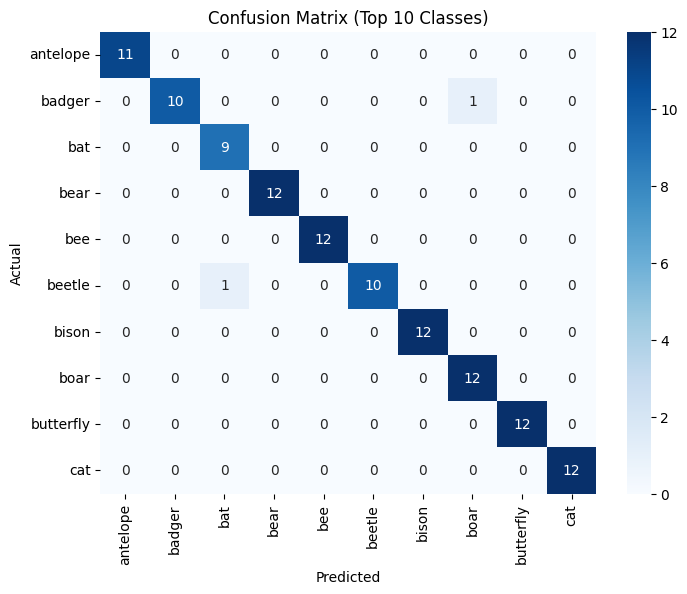

In [15]:
# =============================
# 8. CONFUSION MATRIX (TOP 10)
# =============================
cm = confusion_matrix(all_labels, all_preds)

top_n = 10
cm_small = cm[:top_n, :top_n]
classes = train_data.classes[:top_n]

plt.figure(figsize=(8,6))
sns.heatmap(cm_small, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title("Confusion Matrix (Top 10 Classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
# =============================
# 9. CLASSIFICATION REPORT
# =============================
report = classification_report(
    all_labels,
    all_preds,
    target_names=train_data.classes,
    digits=4
)

print("\nClassification Report:\n")
print(report)

# Save report
os.makedirs("saved_models", exist_ok=True)

with open("saved_models/classification_report.txt", "w") as f:
    f.write(report)


Classification Report:

                precision    recall  f1-score   support

      antelope     0.8462    0.9167    0.8800        12
        badger     1.0000    0.8333    0.9091        12
           bat     0.7500    0.7500    0.7500        12
          bear     1.0000    1.0000    1.0000        12
           bee     1.0000    1.0000    1.0000        12
        beetle     0.7143    0.8333    0.7692        12
         bison     0.9231    1.0000    0.9600        12
          boar     0.9231    1.0000    0.9600        12
     butterfly     0.8571    1.0000    0.9231        12
           cat     0.8571    1.0000    0.9231        12
   caterpillar     1.0000    0.9167    0.9565        12
    chimpanzee     1.0000    0.9167    0.9565        12
     cockroach     1.0000    1.0000    1.0000        12
           cow     0.8182    0.7500    0.7826        12
        coyote     0.9091    0.8333    0.8696        12
          crab     1.0000    0.7500    0.8571        12
          crow     0.7

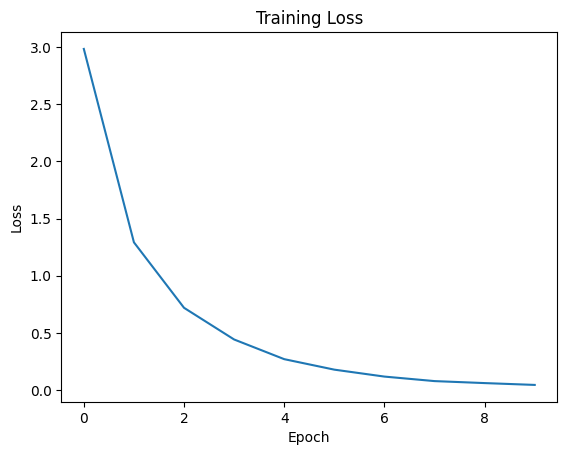

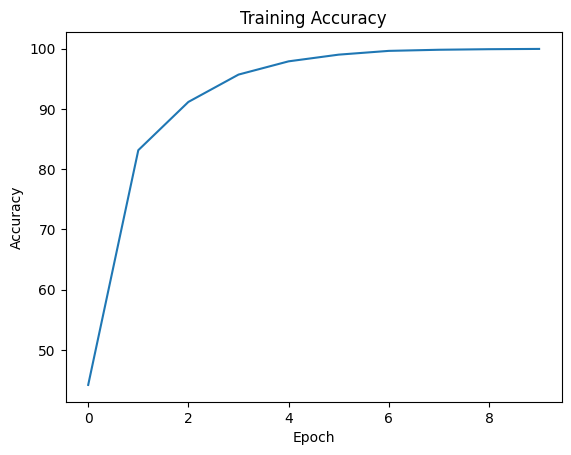

In [17]:
# =============================
# 10. PLOTS
# =============================
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [18]:
# =============================
# 11. SAVE MODEL + CLASSES
# =============================
torch.save(model.state_dict(), "saved_models/animal_classifier.pth")

with open("saved_models/classes.json", "w") as f:
    json.dump(train_data.classes, f)

print("Model and classes.json saved successfully")

Model and classes.json saved successfully
